<a href="https://colab.research.google.com/github/SafiBD/machine-learning/blob/main/Fertility_gap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [29]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
#!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
DATA = '/content/drive/MyDrive/Fertility_Gap/Fertility_gap.xlsx'
df = pd.read_excel(DATA)

In [34]:
print("=" * 60)
print(f"Dataset loaded successfully: {df.shape[0]} rows × {df.shape[1]} columns")
print("=" * 60)

Dataset loaded successfully: 30078 rows × 23 columns


In [35]:
# --- Basic Dataset Info ---
print("─── Dataset Shape ───")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n─── Column Data Types ───")
print(df.dtypes.value_counts())

print("\n─── First 5 Rows ───")
display(df.head())

print("\n─── Descriptive Statistics (Numerical) ───")
display(df.describe())

─── Dataset Shape ───
Rows: 30,078  |  Columns: 23

─── Column Data Types ───
object     21
int64       1
float64     1
Name: count, dtype: int64

─── First 5 Rows ───


,Age in 5-year groups,Division,Type of place of residence,Highest educational level,Frequency of reading newspaper or magazine,Frequency of listening to radio,Frequency of watching television,Wealth index combined,Total children ever born,Age of respondent at 1st birth,...,Decision maker for using contraception,Husband/partner's education level,Respondent currently working,Person who usually decides how to spend respondent's earnings,Person who usually decides on: respondent's health care,Person who usually decides on: large household purchases,Person who usually decides on: visits to family or relatives,Person who usually decides on: what to do with money husband earns,Type of school attended,District
0,45-49,Barishal,Urban,Higher,Not at all,Not at all,At least once a week,Richest,2,21.0,...,Joint decision,Higher,No,NaN,Respondent and husband/partner,Respondent and husband/partner,Respondent and husband/partner,Respondent and husband/partner,School,Barishal
1,45-49,Barishal,Urban,Secondary,Not at all,Not at all,At least once a week,Richer,3,17.0,...,Joint decision,Secondary,No,NaN,Respondent alone,Respondent and husband/partner,Respondent alone,Husband/partner has no earnings,School,Barishal
2,25-29,Barishal,Urban,Secondary,Not at all,Not at all,At least once a week,Richer,2,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School,Barishal
3,40-44,Barishal,Urban,Primary,Not at all,Not at all,At least once a week,Richer,2,23.0,...,Joint decision,Primary,No,NaN,Respondent and husband/partner,Respondent and husband/partner,Respondent and husband/partner,Respondent and husband/partner,School,Barishal
4,45-49,Barishal,Urban,Primary,Not at all,Not at all,At least once a week,Richest,4,13.0,...,Joint decision,No education,Yes,Respondent alone,Respondent and husband/partner,Husband/partner alone,Respondent and husband/partner,Respondent and husband/partner,School,Barishal



─── Descriptive Statistics (Numerical) ───


,Total children ever born,Age of respondent at 1st birth
count,30078.000000,26933.000000
mean,2.151805,18.848067
std,1.406539,3.650492
min,0.000000,10.000000
25%,1.000000,16.000000
50%,2.000000,18.000000
75%,3.000000,21.000000
max,11.000000,47.000000


In [ ]:
df.info

In [36]:
import pandas as pd
import numpy as np

# Re-initialize df to the state right before ordinal encoding (like in lNPxkpShiaVq)
# This ensures the updated mapping is applied to the original string values.
DATA = '/content/drive/MyDrive/Fertility_Gap/Fertility_gap.xlsx'
df = pd.read_excel(DATA)

# Apply pre-processing steps from previous cells to get df to the state before ordinal encoding
df['Ideal number of children'] = pd.to_numeric(df['Ideal number of children'], errors='coerce')
df['Total children ever born'] = pd.to_numeric(df['Total children ever born'], errors='coerce')
df['fertility_gap'] = df['Ideal number of children'] - df['Total children ever born']
df.replace([98, 99], np.nan, inplace=True)
df = df.dropna()

# Remove leakage variables (from cell 0DK-3nTwJXyJ)
df = df.drop(columns=['Ideal number of children', 'Total children ever born'])

print("Re-running ordinal encoding with updated education mapping...")

# Define custom mappings for ordinal features, including the user's request for 'Don't know'

# 1. Age in 5-year groups: 'below 20=0 and above 20=1'
age_group_mapping = {
    '10-14': 0, '15-19': 0,
    '20-24': 1, '25-29': 1, '30-34': 1,
    '35-39': 1, '40-44': 1, '45-49': 1
}
df['Age in 5-year groups'] = df['Age in 5-year groups'].map(age_group_mapping).fillna(-1).astype(int)

# 2. Age of respondent at 1st birth: 'below 20=0, above 20=1'
df['Age at 1st birth_binary'] = (df['Age of respondent at 1st birth'] >= 20).astype(int)
df = df.drop(columns=['Age of respondent at 1st birth'])

# 3. Highest educational level and Husband/partner's education level
education_mapping = {
    'No education': 0,
    'Primary': 0, # Mapped to 0 (lower education)
    'Secondary': 1, # Mapped to 1 (higher education)
    'Higher': 1, # Mapped to 1 (higher education)
    "Don't know": 0 # Mapped to 0 (lower education)
}
df['Highest educational level'] = df['Highest educational level'].map(education_mapping).fillna(-1).astype(int)
df["Husband/partner's education level"] = df["Husband/partner's education level"].map(education_mapping).fillna(-1).astype(int)

# 4. Frequency of reading newspaper or magazine, listening to radio, watching television
frequency_mapping = {
    'Not at all': 0, # Mapped to 0 (less frequent)
    'Less than once a week': 0, # Mapped to 0 (less frequent)
    'At least once a week': 1, # Mapped to 1 (more frequent)
    'Almost every day': 1 # Mapped to 1 (more frequent)
}
df['Frequency of reading newspaper or magazine'] = df['Frequency of reading newspaper or magazine'].map(frequency_mapping).fillna(-1).astype(int)
df['Frequency of listening to radio'] = df['Frequency of listening to radio'].map(frequency_mapping).fillna(-1).astype(int)
df['Frequency of watching television'] = df['Frequency of watching television'].map(frequency_mapping).fillna(-1).astype(int)

# 5. Respondent currently working and Currently pregnant
working_mapping = {
    'No': 0,
    'Yes': 1
}
df['Respondent currently working'] = df['Respondent currently working'].map(working_mapping).fillna(-1).astype(int)
df['Currently pregnant'] = df['Currently pregnant'].map(working_mapping).fillna(-1).astype(int)

# 6. Decision-maker roles
dc_contraception_mapping = {
    'Husband/partner': 0, # Mapped to 0 (respondent/shared control)
    'Joint decision': 0, # Mapped to 0 (respondent/shared control)
    'Respondent': 1, # Mapped to 1 (external control)
    'Someone else': 1, # Mapped to 1 (external control)
    'Other': 1
    }
dc_res_earn_hc_mapping = {
    'Husband/partner alone': 0, # Mapped to 0 (respondent/shared control)
    'Respondent and husband/partner': 0, # Mapped to 0 (respondent/shared control)
    'Respondent alone': 1, # Mapped to 1 (external control)
    'Someone else': 1, # Mapped to 1 (external control)
    'Other': 1
    }
dc_res_hs_earn_mapping = {
    'Husband/partner alone': 0, # Mapped to 0 (respondent/shared control)
    'Respondent and husband/partner': 0, # Mapped to 0 (respondent/shared control)
    'Respondent alone': 1, # Mapped to 1 (external control)
    'Husband/partner has no earnings': 1, # Mapped to 1 (external control)
    'Other': 1
    }
df['Decision maker for using contraception'] = df['Decision maker for using contraception'].map(dc_contraception_mapping).fillna(-1).astype(int)
df["Person who usually decides how to spend respondent's earnings"] = df["Person who usually decides how to spend respondent's earnings"].map(dc_res_hs_earn_mapping).fillna(-1).astype(int)
df["Person who usually decides on: respondent's health care"] = df["Person who usually decides on: respondent's health care"].map(dc_res_earn_hc_mapping).fillna(-1).astype(int)
df["Person who usually decides on: large household purchases"] = df["Person who usually decides on: large household purchases"].map(dc_res_earn_hc_mapping).fillna(-1).astype(int)
df["Person who usually decides on: visits to family or relatives"] = df["Person who usually decides on: visits to family or relatives"].map(dc_res_earn_hc_mapping).fillna(-1).astype(int)
df["Person who usually decides on: what to do with money husband earns"] = df["Person who usually decides on: what to do with money husband earns"].map(dc_res_earn_hc_mapping).fillna(-1).astype(int)

# 7. Wealth index combined and Type of place of residence
wealth_index_mapping = {
    'Poorest': 0, 'Poorer': 0, 'Middle': 0, # Mapped to 0 (lower wealth)
    'Richer': 1, 'Richest': 1 # Mapped to 1 (higher wealth)
}
residence_type_mapping = {
    'Rural': 0, 'Urban': 1
}
df['Wealth index combined'] = df['Wealth index combined'].map(wealth_index_mapping).fillna(-1).astype(int)
df['Type of place of residence'] = df['Type of place of residence'].map(residence_type_mapping).fillna(-1).astype(int)

# 8. Remaining nominal features
print("\nApplying arbitrary ordinal encoding for remaining nominal features (based on alphabetical order):\n")
for col in ['Division', 'Current contraceptive method', 'Type of school attended', 'District']:
    unique_values = sorted(df[col].unique())
    arbitrary_mapping = {val: i for i, val in enumerate(unique_values)}
    df[col] = df[col].map(arbitrary_mapping).fillna(-1).astype(int)
    print(f"- '{col}' encoded with {len(unique_values)} categories.")

print("\nAll specified and remaining categorical features have been numerically encoded with the updated 'education_mapping'.")
print("\nFirst 5 rows of selected encoded columns:")
display(df[['Age in 5-year groups', 'Age at 1st birth_binary', 'Highest educational level',
            'Frequency of reading newspaper or magazine', 'Respondent currently working',
            'Division', 'Wealth index combined']].head())
print("\nData types of selected encoded columns:")
print(df[['Age in 5-year groups', 'Age at 1st birth_binary', 'Highest educational level',
            'Frequency of reading newspaper or magazine', 'Respondent currently working',
            'Division', 'Wealth index combined']].dtypes)

print("\nRemaining object columns (if any):")
print(df.select_dtypes(include='object').columns.tolist())

Re-running ordinal encoding with updated education mapping...

Applying arbitrary ordinal encoding for remaining nominal features (based on alphabetical order):

- 'Division' encoded with 8 categories.
- 'Current contraceptive method' encoded with 14 categories.
- 'Type of school attended' encoded with 2 categories.
- 'District' encoded with 64 categories.

All specified and remaining categorical features have been numerically encoded with the updated 'education_mapping'.

First 5 rows of selected encoded columns:


,Age in 5-year groups,Age at 1st birth_binary,Highest educational level,Frequency of reading newspaper or magazine,Respondent currently working,Division,Wealth index combined
4,1,0,0,0,1,0,1
6,1,1,1,1,0,0,1
11,1,0,1,0,1,0,1
16,1,1,1,0,1,0,1
34,1,0,1,0,1,0,1



Data types of selected encoded columns:
Age in 5-year groups                          int64
Age at 1st birth_binary                       int64
Highest educational level                     int64
Frequency of reading newspaper or magazine    int64
Respondent currently working                  int64
Division                                      int64
Wealth index combined                         int64
dtype: object

Remaining object columns (if any):
[]


In [37]:
df.fertility_gap

,fertility_gap
4,-2.0
6,0.0
11,1.0
16,1.0
34,0.0
...,...
29961,-3.0
29972,-4.0
29984,-1.0
30009,1.0


In [38]:
df.columns

Index(['Age in 5-year groups', 'Division', 'Type of place of residence',
       'Highest educational level',
       'Frequency of reading newspaper or magazine',
       'Frequency of listening to radio', 'Frequency of watching television',
       'Wealth index combined', 'Currently pregnant',
       'Current contraceptive method',
       'Decision maker for using contraception',
       'Husband/partner's education level', 'Respondent currently working',
       'Person who usually decides how to spend respondent's earnings',
       'Person who usually decides on: respondent's health care',
       'Person who usually decides on: large household purchases',
       'Person who usually decides on: visits to family or relatives',
       'Person who usually decides on: what to do with money husband earns',
       'Type of school attended', 'District', 'fertility_gap',
       'Age at 1st birth_binary'],
      dtype='object')

In [39]:
# Define the path to save the cleaned dataset in Google Drive
save_path = '/content/drive/MyDrive/Fertility_Gap/Fertility_gap_cleaned.xlsx'

# Save the DataFrame to an Excel file
df.to_excel(save_path, index=False) # index=False prevents writing the DataFrame index as a column

print(f"Cleaned dataset saved successfully to {save_path}")

Cleaned dataset saved successfully to /content/drive/MyDrive/Fertility_Gap/Fertility_gap_cleaned.xlsx


In [40]:
# 8. Define Features and Target
# ==============================
X = df.drop('fertility_gap', axis=1)
y = df['fertility_gap']

In [41]:
# 10. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [42]:
# 11. Train Model
# ==============================
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [43]:
# 12. Evaluate Model
# ==============================
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)


RMSE: 1.1435210419421977
R²: 0.01735448259781147


In [44]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(100, 500), # Number of trees in the forest
    'max_features': ['auto', 'sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': randint(10, 50), # Maximum number of levels in tree
    'min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10), # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False] # Method of selecting samples for training each tree
}

# Initialize RandomizedSearchCV
# n_iter controls the number of parameter settings that are sampled. More is better but takes longer.
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50, # Number of random combinations to try
    cv=5, # 5-fold cross-validation
    verbose=2, # Verbosity level
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV to the training data
print("Starting RandomizedSearchCV for hyperparameter tuning...")
random_search.fit(X_train, y_train)

print("\nRandomizedSearchCV complete.")
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation R² score: ", random_search.best_score_)

# Get the best model
best_rf_model = random_search.best_estimator_


Starting RandomizedSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

RandomizedSearchCV complete.
Best parameters found:  {'bootstrap': True, 'max_depth': 26, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 6, 'n_estimators': 471}
Best cross-validation R² score:  0.12433786978669017


Now that we have the best hyperparameters from `RandomizedSearchCV`, let's evaluate the performance of this `best_rf_model` on the test set.

### 1. Linear Regression Model

In [45]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Model RMSE:", rmse_linear)
print("Linear Regression Model R²:", r2_linear)

# Display coefficients for interpretability
print("\nLinear Regression Coefficients (Top 10):")
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': linear_model.coef_})
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
display(coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(10))


Linear Regression Model RMSE: 1.0657499151308307
Linear Regression Model R²: 0.14646925415994783

Linear Regression Coefficients (Top 10):


,Feature,Coefficient,Abs_Coefficient
0,Age in 5-year groups,-1.133351,1.133351
3,Highest educational level,0.342724,0.342724
20,Age at 1st birth_binary,0.325020,0.325020
8,Currently pregnant,0.302194,0.302194
11,Husband/partner's education level,0.193325,0.193325
18,Type of school attended,-0.162228,0.162228
5,Frequency of listening to radio,0.161885,0.161885
17,Person who usually decides on: what to do with...,0.122490,0.122490
15,Person who usually decides on: large household...,0.099293,0.099293
14,Person who usually decides on: respondent's he...,-0.081571,0.081571


### 2. Light Gradient Boosting Machine (LightGBM) Model

In [46]:
import lightgbm as lgb
import re

# Sanitize column names for LightGBM compatibility
def sanitize_column_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        # Replace problematic characters with underscore
        new_col = re.sub(r'[^A-Za-z0-9_]+', '_', col)
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_lgbm = sanitize_column_names(X_train.copy())
X_test_lgbm = sanitize_column_names(X_test.copy())

# Initialize and train the LightGBM model
# Using default parameters for a quick test, tuning would further improve performance
lgbm_model = lgb.LGBMRegressor(random_state=42)
lgbm_model.fit(X_train_lgbm, y_train)

# Make predictions
y_pred_lgbm = lgbm_model.predict(X_test_lgbm)

# Evaluate the model
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("LightGBM Model RMSE:", rmse_lgbm)
print("LightGBM Model R²:", r2_lgbm)

# Display feature importances for LightGBM
print("\nLightGBM Feature Importances (Top 10):")
feature_importance_df = pd.DataFrame({'Feature': X_train_lgbm.columns, 'Importance': lgbm_model.feature_importances_})
display(feature_importance_df.sort_values(by='Importance', ascending=False).head(10))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002402 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 123
[LightGBM] [Info] Number of data points in the train set: 3849, number of used features: 21
[LightGBM] [Info] Start training from score -0.093791
LightGBM Model RMSE: 1.0803514771441436
LightGBM Model R²: 0.12292103278369582

LightGBM Feature Importances (Top 10):


,Feature,Importance
19,District,746
9,Current_contraceptive_method,470
1,Division,367
6,Frequency_of_watching_television,152
13,Person_who_usually_decides_how_to_spend_respon...,148
11,Husband_partner_s_education_level,133
3,Highest_educational_level,126
7,Wealth_index_combined,119
2,Type_of_place_of_residence,108
20,Age_at_1st_birth_binary,100


In [47]:
# Make predictions with the best model
y_pred_best_rf = best_rf_model.predict(X_test)

# Evaluate the best model
rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print("Improved Model RMSE:", rmse_best_rf)
print("Improved Model R²:", r2_best_rf)


Improved Model RMSE: 1.0587069454563638
Improved Model R²: 0.1577130329186398


After hyperparameter tuning, we can analyze feature importances to understand which features contribute most to the model's predictions. This can help guide further feature engineering or selection efforts. Since SHAP is already imported, we can use it for this analysis.

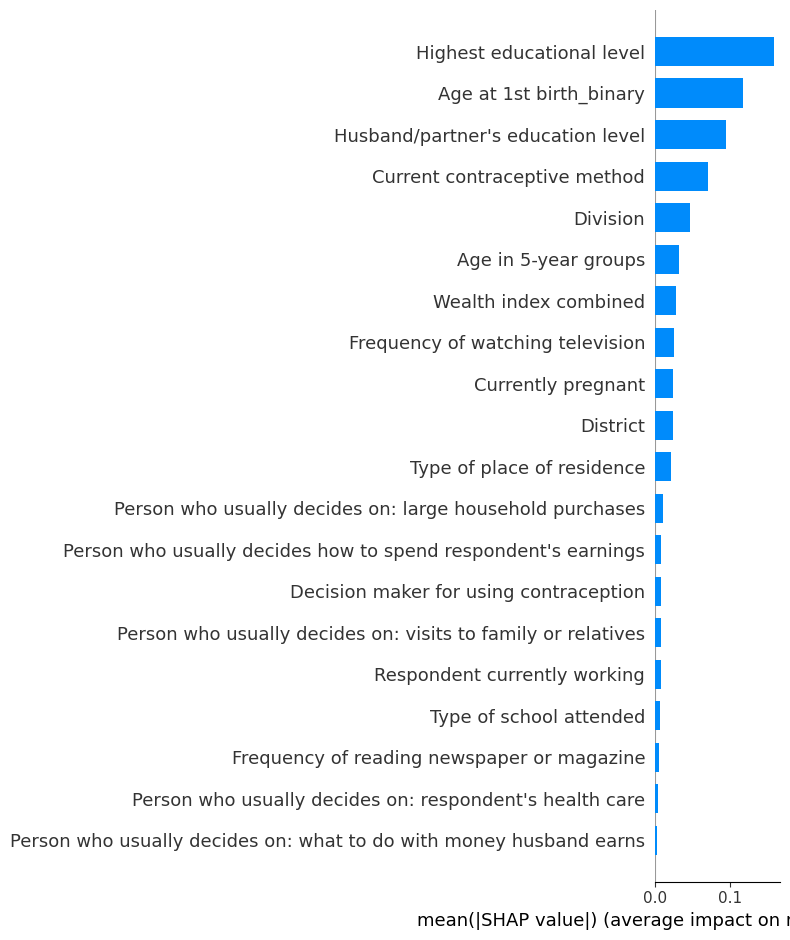

In [48]:
# Calculate SHAP values
explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test)

# Plot summary of feature importances
shap.summary_plot(shap_values, X_test, plot_type="bar")
